# Projet Machine Learning — Prédiction du poste d'un joueur
### FIFA World Cup 2026 — Player Performance Dataset

**Auteur :** Kiritheepan Robinsan — ENSEA · Barcelona Summer Course 2026
**Variable cible :** `position` — classification **multiclasse** à 4 classes
(Defender · Forward · Goalkeeper · Midfielder)

---

## Continuité avec l'expérience précédente

L'énoncé demande d'utiliser **le même jeu de données et la même variable cible** que lors de
l'expérience précédente. Celle-ci était le notebook **`S5_P1_Fifa_Multiclasse`**, où je prédisais
déjà `position` sur ce dataset avec un arbre de décision, un KNN (k réglé de 1 à 50) et un
Naive Bayes — meilleur résultat obtenu : **89 % d'accuracy** avec le KNN.

Ce projet reprend donc la même cible, avec trois nouveaux modèles et une méthodologie renforcée :

| Point | S5 (précédent) | Ce projet |
|---|---|---|
| Modèles | Arbre → KNN → Naive Bayes | Arbre · **Random Forest** · **Gradient Boosting** + GridSearchCV |
| Split train/test | aléatoire, ligne par ligne | **par joueur** (voir plus bas — c'est crucial) |
| Métrique | `balanced_accuracy` | **F1 macro** |
| Interprétabilité | `feature_importances_` brut | importance native **vs** permutation + **SHAP** |
| Non supervisé | absent | PCA · ICA · t-SNE + KMeans · DBSCAN |

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)

df = pd.read_csv("../Data/fifa_world_cup_2026_player_performance.csv")
print(df.shape, "|", df["player_id"].nunique(), "joueurs |", df.isna().sum().sum(), "valeurs manquantes")

(54600, 75) | 1248 joueurs | 0 valeurs manquantes

## Partie 0 — Exploration et préparation

### La cible : 4 postes, modérément déséquilibrés

In [ ]:
df["position"].value_counts()

position
Defender      18900
Midfielder    16800
Forward       12600
Goalkeeper     6300
Name: count, dtype: int64

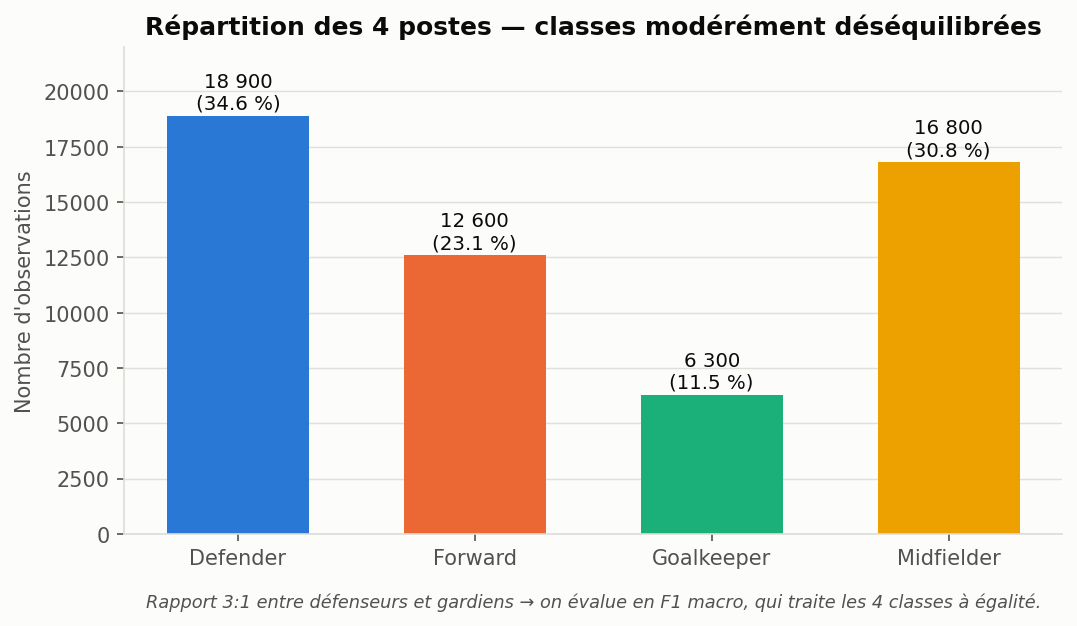

In [ ]:
# on visualise la repartition des 4 classes
plt.savefig("resultats/repartition_postes.png", dpi=150, bbox_inches="tight")
plt.show()

**Le rapport est de 3:1** entre les défenseurs (18 900) et les gardiens (6 300). Ce n'est pas un
déséquilibre extrême, mais suffisant pour écarter l'accuracy simple comme métrique unique : on
utilisera le **F1 macro**, qui calcule le F1 de chaque classe puis en fait la moyenne **non pondérée**
— les 4 postes comptent donc à égalité, et le modèle ne peut pas « gagner » en négligeant les gardiens.

### ⚠️ Une fuite de données à détecter avant tout

Avant de modéliser, il faut chercher les variables qui **trahissent trivialement** la réponse.
`jersey_number` est le suspect évident : au football, les numéros ne sont pas attribués au hasard.

In [ ]:
# le numero de maillot est-il lie au poste ?
df.groupby("position")["jersey_number"].agg(["min", "max", "nunique"])

            min  max  nunique
position
Defender      4   12        9
Forward      21   26        6
Goalkeeper    1    3        3
Midfielder   13   20        8

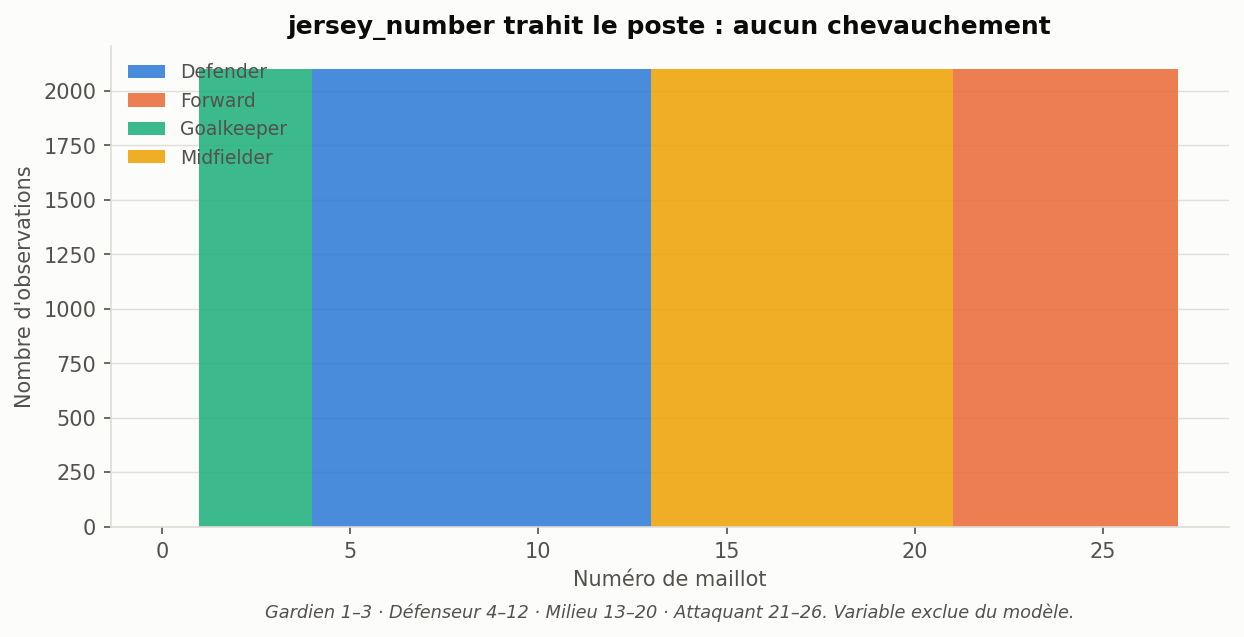

In [ ]:
# on trace la distribution des numeros par poste
plt.savefig("resultats/fuite_jersey_number.png", dpi=150, bbox_inches="tight")
plt.show()

**Les plages ne se chevauchent absolument pas** : Gardien 1–3, Défenseur 4–12, Milieu 13–20,
Attaquant 21–26. Une seule règle `if jersey_number <= 3 then Goalkeeper...` donnerait **100 %
d'accuracy** sans rien apprendre du jeu.

C'est une **fuite de données** au sens strict : le numéro est attribué *parce que* le joueur occupe
ce poste, il n'est pas une caractéristique de son jeu. Le garder rendrait le projet vide de sens.
→ **`jersey_number` est exclu.**

> Note : les statistiques propres aux gardiens (`saves`, `punches`, `clean_sheet`…) valent exactement 0
> pour tous les joueurs de champ. Elles rendent la classe Goalkeeper facile, mais on les **garde** :
> ce sont de véritables actions de match, pas une convention. Un modèle qui déduit « ce joueur a fait
> des arrêts, donc c'est un gardien » raisonne correctement.

### Encodage et exclusions

In [ ]:
# identifiants et variables a trop forte cardinalite : aucune valeur predictive
EXCLURE = ["player_id", "player_name", "match_id", "match_date", "stadium", "city",
           "team", "opponent_team", "nationality", "club_name",
           "jersey_number"]   # <-- la fuite identifiee juste avant

df_encoded = pd.get_dummies(df, columns=["preferred_foot", "tournament_stage", "match_result"],
                            drop_first=True)
df_final = df_encoded.drop(columns=EXCLURE)

colonnes_bool = df_final.select_dtypes(include="bool").columns
df_final[colonnes_bool] = df_final[colonnes_bool].astype(int)
df_final.shape

(54600, 70)

### La séparation train / test : pourquoi elle doit se faire PAR JOUEUR

Chaque joueur apparaît environ **44 fois** (une ligne par match). Et surtout : **son poste ne change
jamais d'un match à l'autre.**

Avec un `train_test_split` classique, ligne par ligne, le même joueur se retrouverait des deux côtés.
Le modèle pourrait alors **mémoriser** « ce profil de joueur = défenseur » au lieu d'apprendre ce qui
caractérise un défenseur. Le score de test serait flatteur mais faux — c'est une **fuite de données**.

C'est le point que mon notebook S5 ne traitait pas. On sépare donc les **1 248 joueurs**, pas les lignes.

In [ ]:
from sklearn.model_selection import train_test_split

joueurs = np.array(df["player_id"].unique())
joueurs_train, joueurs_test = train_test_split(joueurs, test_size=0.2, random_state=42)

masque_train = df["player_id"].isin(joueurs_train).values
X = df_final.drop(columns=["position"])
y = df_final["position"]

X_train, X_test = X[masque_train], X[~masque_train]
y_train, y_test = y[masque_train], y[~masque_train]

# controle : aucun joueur ne doit etre des deux cotes
communs = set(df.loc[masque_train, "player_id"]) & set(df.loc[~masque_train, "player_id"])
print(X_train.shape, X_test.shape, "| joueurs communs :", len(communs))

(43726, 69) (10874, 69) | joueurs communs : 0

## Partie 1 — Apprentissage supervisé

Trois modèles réglés par `GridSearchCV` avec `scoring="f1_macro"`, puis évalués sur le **même**
jeu de test (10 874 lignes, joueurs jamais vus).

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

grilles = {
    "Arbre de décision": (DecisionTreeClassifier(random_state=42),
                          {"max_depth": [5, 10, None], "min_samples_leaf": [1, 5, 20]}),
    "Random Forest":     (RandomForestClassifier(random_state=42, n_jobs=-1),
                          {"n_estimators": [200], "max_depth": [10, None], "min_samples_leaf": [1, 5]}),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=42),
                          {"n_estimators": [100], "learning_rate": [0.1], "max_depth": [3, 5]}),
}

modeles, predictions = {}, {}
for nom, (estimateur, grille) in grilles.items():
    gs = GridSearchCV(estimateur, grille, cv=3, scoring="f1_macro", n_jobs=-1)
    gs.fit(X_train, y_train)
    modeles[nom] = gs
    predictions[nom] = gs.predict(X_test)
    print(f"{nom:20s} F1 macro (CV) = {gs.best_score_:.3f}  |  {gs.best_params_}")

Arbre de décision    F1 macro (CV) = 0.926  |  {'max_depth': None, 'min_samples_leaf': 5}
Random Forest        F1 macro (CV) = 0.967  |  {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Gradient Boosting    F1 macro (CV) = 0.976  |  {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report)

for nom, gs in modeles.items():
    yp = predictions[nom]
    proba = gs.predict_proba(X_test)
    print(f"{nom:20s} acc={accuracy_score(y_test, yp):.3f}  "
          f"prec={precision_score(y_test, yp, average='macro'):.3f}  "
          f"rec={recall_score(y_test, yp, average='macro'):.3f}  "
          f"F1={f1_score(y_test, yp, average='macro'):.3f}  "
          f"AUC={roc_auc_score(y_test, proba, multi_class='ovr', average='macro'):.3f}")

Arbre de décision    acc=0.914  prec=0.918  rec=0.913  F1=0.915  AUC=0.960
Random Forest        acc=0.958  prec=0.961  rec=0.955  F1=0.958  AUC=0.997
Gradient Boosting    acc=0.958  prec=0.960  rec=0.956  F1=0.958  AUC=0.997

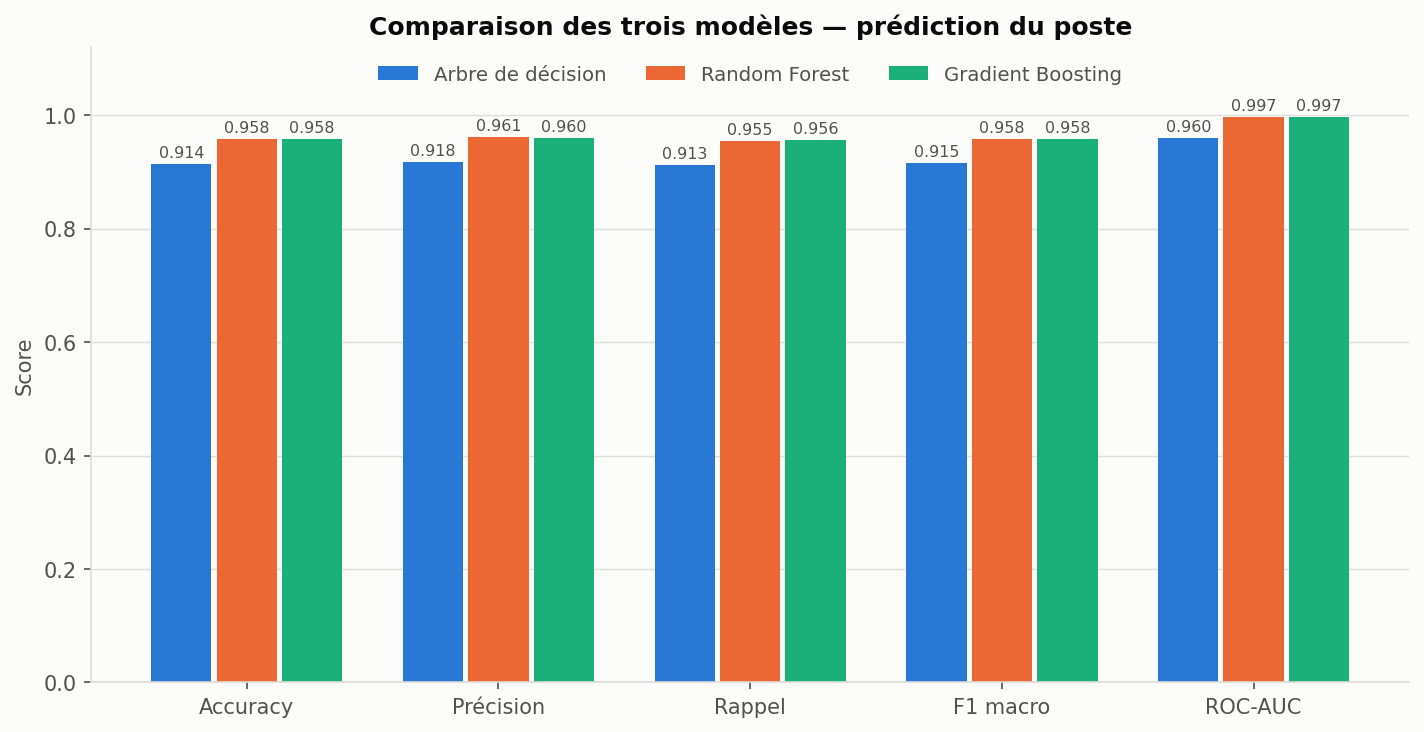

In [ ]:
# comparaison visuelle des metriques
plt.savefig("resultats/comparaison_metriques.png", dpi=150, bbox_inches="tight")
plt.show()

### Lecture des résultats

**Random Forest et Gradient Boosting sont à égalité** (0.958 de F1 macro),
loin devant l'arbre seul (0.915). L'AUC de **0,997** indique une
séparation quasi parfaite des 4 classes.

**Comparaison avec mon S5 :** le KNN atteignait 89 % d'accuracy avec un split aléatoire. Ici on
obtient **95,8 %** avec un split *plus strict* (par joueur). Le gain vient donc bien des modèles
d'ensemble, pas d'une fuite — au contraire, on a supprimé celle qui existait.

### Matrices de confusion

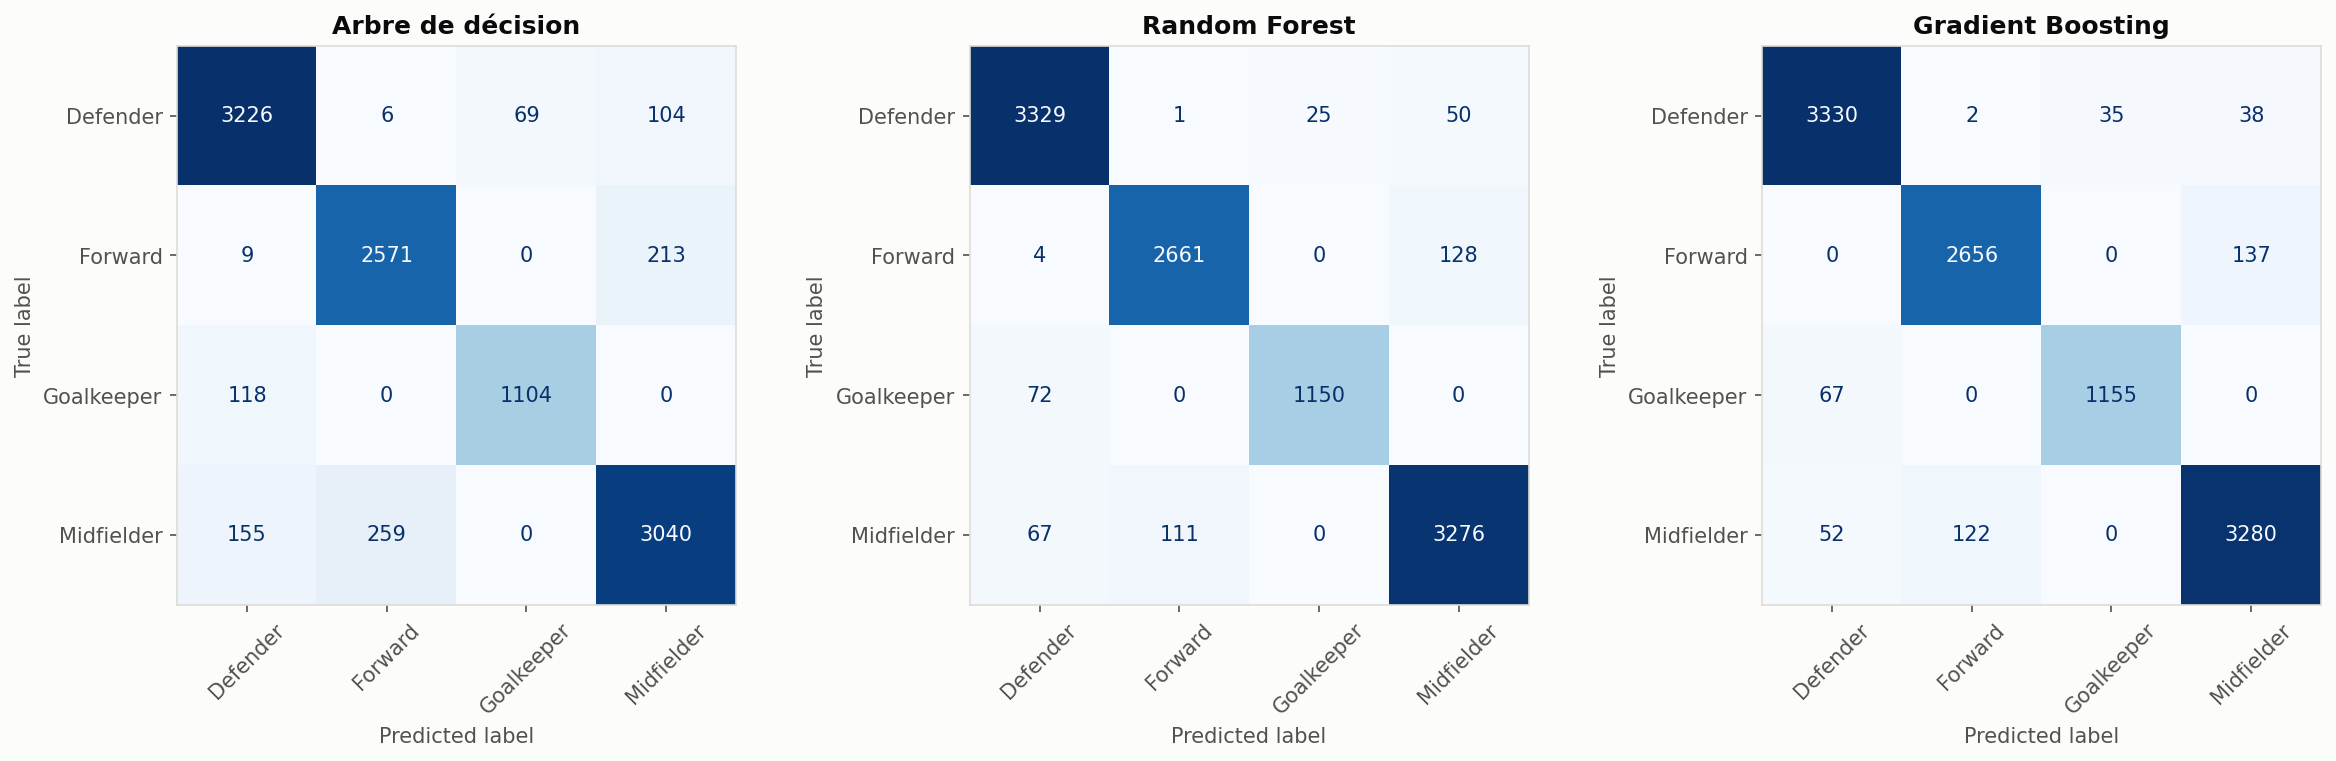

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.savefig("resultats/matrices_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print(classification_report(y_test, predictions["Random Forest"]))

              precision    recall  f1-score   support

    Defender       0.959     0.978     0.968      3405
     Forward       0.960     0.953     0.956      2793
  Goalkeeper       0.979     0.941     0.960      1222
  Midfielder       0.948     0.948     0.948      3454

    accuracy                           0.958     10874
   macro avg       0.961     0.955     0.958     10874

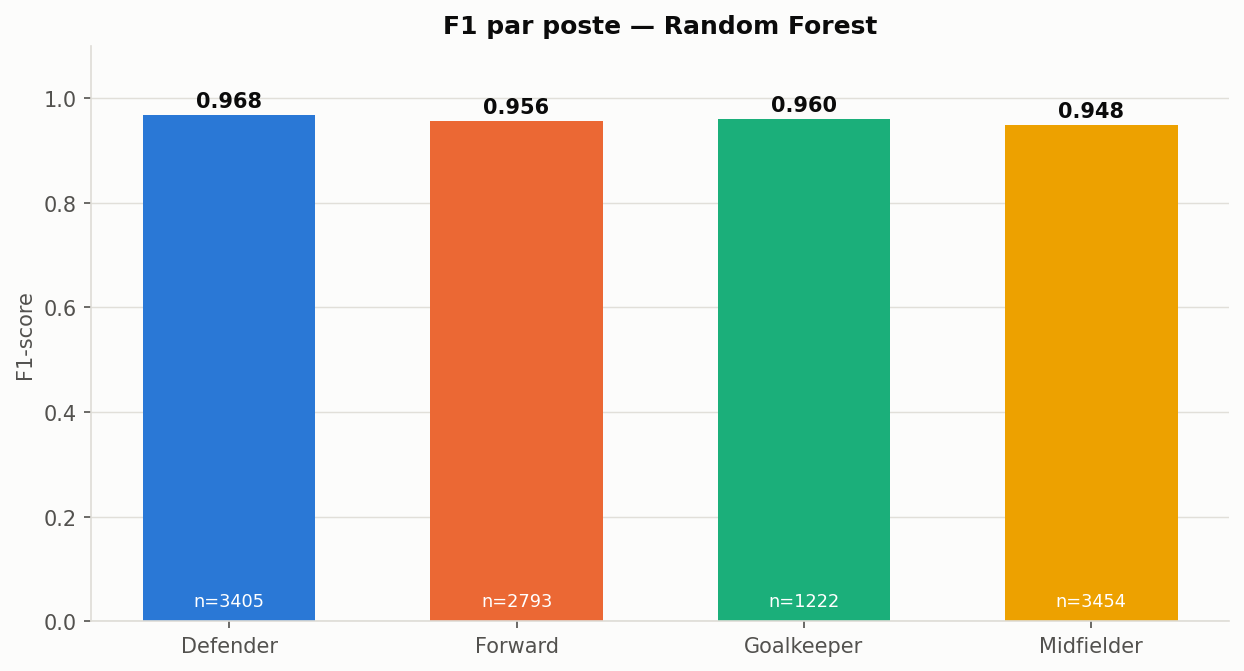

In [ ]:
# F1 par poste
plt.savefig("resultats/f1_par_poste.png", dpi=150, bbox_inches="tight")
plt.show()

### Faux positifs et faux négatifs — en multiclasse

En multiclasse, chaque erreur est **à la fois** un faux négatif pour la vraie classe et un faux
positif pour la classe prédite. La matrice de confusion de la Random Forest le montre précisément :

| Confusion | Nombre | Lecture footballistique |
|---|---|---|
| Attaquant → Milieu | 128 | la frontière la plus floue |
| Milieu → Attaquant | 111 | ↔ les milieux offensifs et attaquants ont des profils proches |
| Gardien → Défenseur | 72 | des gardiens peu sollicités (0 arrêt sur le match) |
| Milieu → Défenseur | 67 | milieux défensifs |
| Défenseur → Milieu | 50 | défenseurs très portés vers l'avant |

**L'erreur dominante — attaquant ↔ milieu (239 cas) — a un sens réel.** Un milieu offensif et un
attaquant produisent des statistiques très semblables : tirs, passes clés, dribbles. Ce n'est pas
un défaut du modèle mais le reflet d'une frontière tactique réellement continue.

**Le cas des gardiens est le plus intéressant.** Leur précision est excellente (0,979) : quand le
modèle annonce « gardien », il a presque toujours raison. Mais leur rappel est plus faible (0,941) :
il en rate 72. L'explication tient aux données — seuls **2 005 gardiens sur 6 300** ont au moins un
arrêt sur le match. Un gardien à 0 arrêt, 0 sortie, 0 dégagement ressemble statistiquement à un
défenseur passif.

**Quelle erreur est la plus grave ?** Cela dépend de l'usage :
- pour un **recruteur** qui cherche des gardiens, le rappel prime (ne pas en rater un) ;
- pour un **système d'étiquetage automatique**, la précision prime (ne pas polluer la base).

### Courbes ROC (complément)

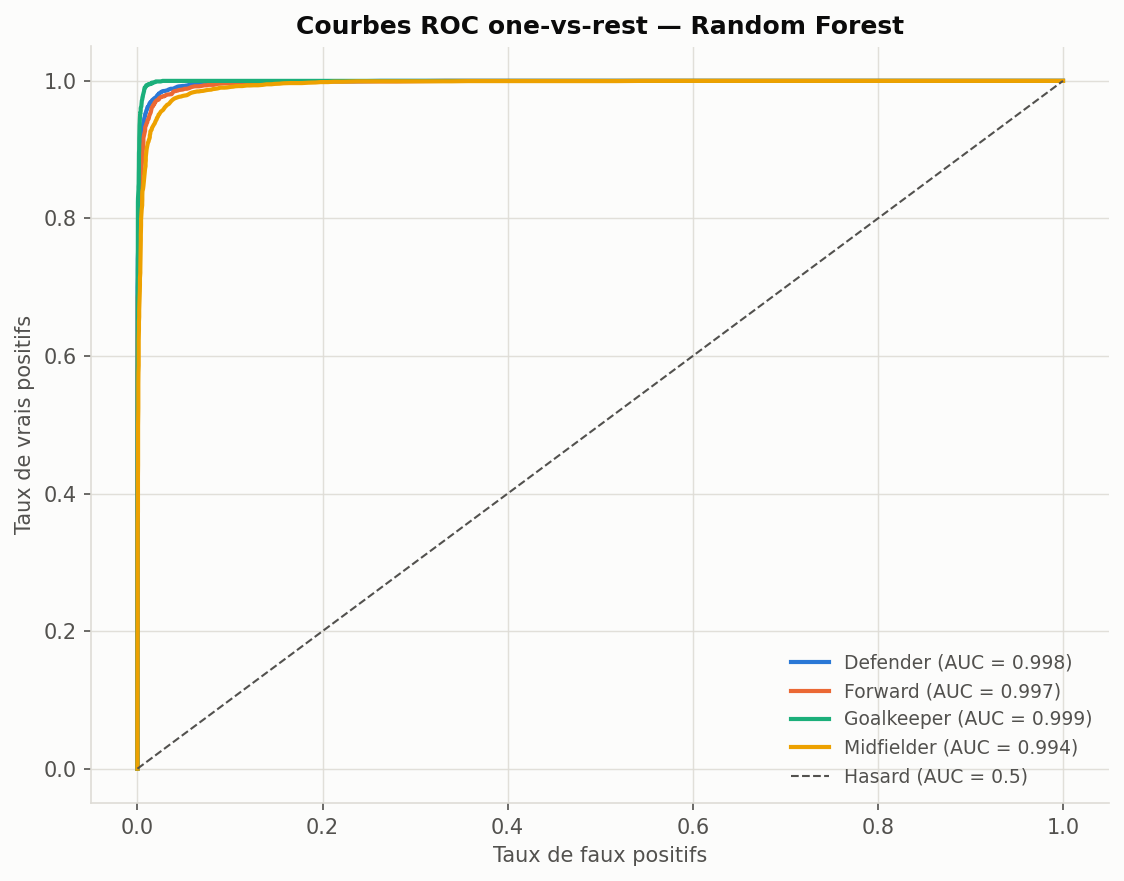

In [ ]:
from sklearn.metrics import roc_curve

plt.savefig("resultats/courbes_roc.png", dpi=150, bbox_inches="tight")
plt.show()

Les courbes sont tracées **one-vs-rest** : chaque classe est opposée à toutes les autres. Elles
montent quasiment à l'angle supérieur gauche, avec des AUC proches de 1 — le modèle sépare
excellemment les 4 postes, à tous les seuils de décision.

## Partie 2 — Importance des variables & SHAP

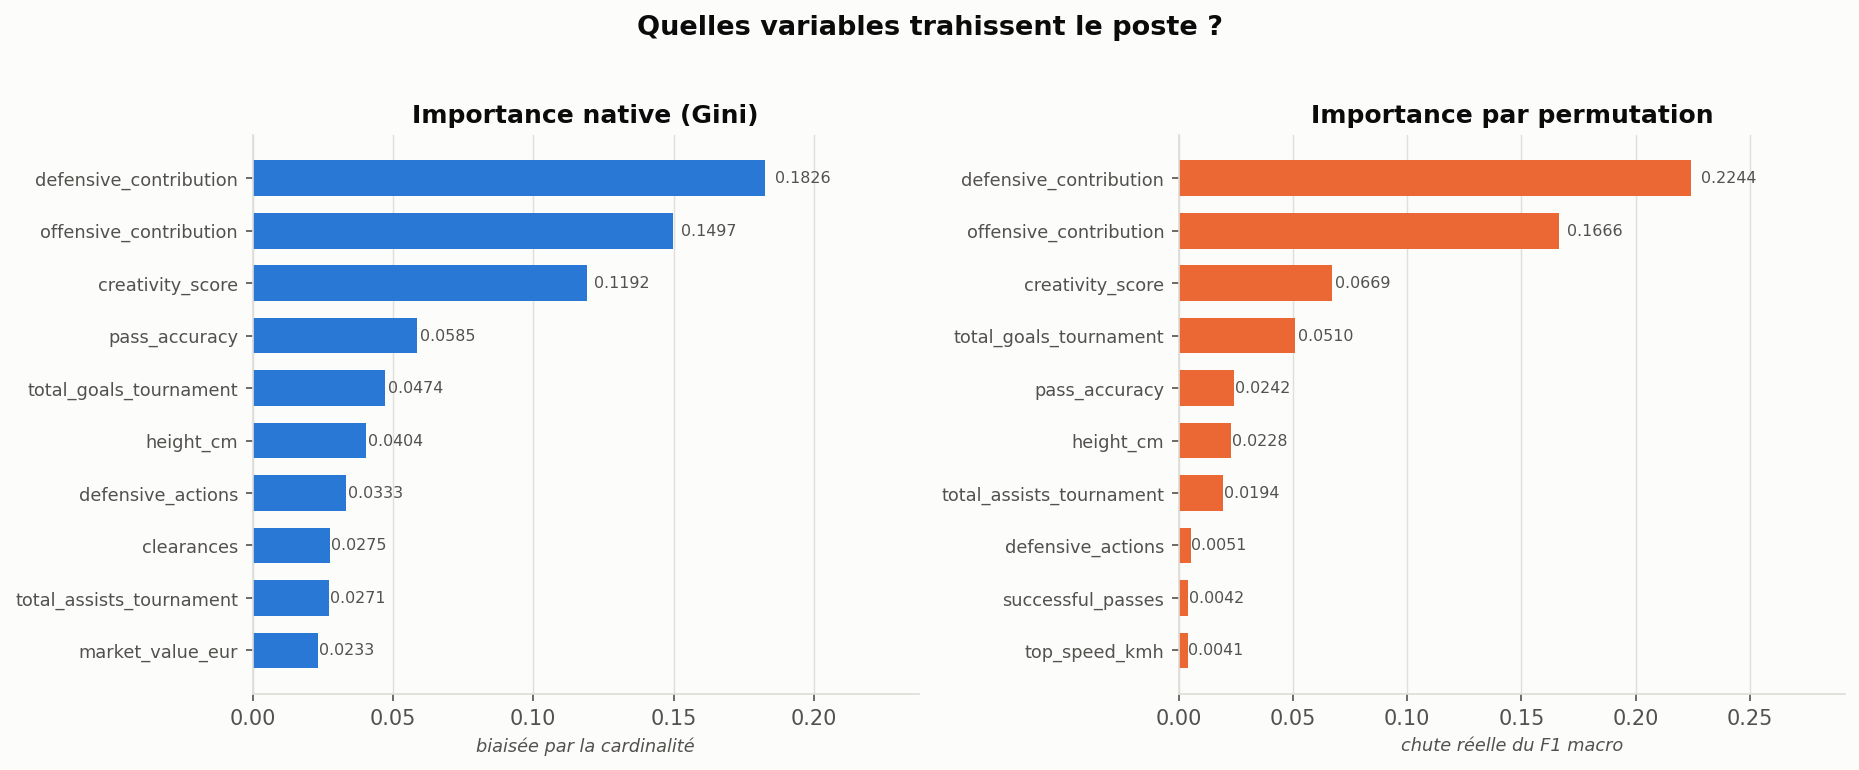

In [ ]:
# importance native (Gini) vs importance par permutation
from sklearn.inspection import permutation_importance

plt.savefig("resultats/importance_comparaison.png", dpi=150, bbox_inches="tight")
plt.show()

### Un résultat cohérent, cette fois

Les deux méthodes **classent les variables dans le même ordre** :
`defensive_contribution`, `offensive_contribution`, `creativity_score`, puis
`total_goals_tournament`, `pass_accuracy` et `height_cm`.

C'est très différent du cas où l'importance native est trompeuse : ici, l'accord entre les deux
mesures et le **sens footballistique évident** des variables retenues confirment que le modèle a
appris quelque chose de réel. Un défenseur se caractérise par sa contribution défensive, un
attaquant par sa contribution offensive et ses buts, un milieu par sa créativité et sa précision de
passe — et `height_cm` capte les gardiens et défenseurs centraux, plus grands en moyenne.

### SHAP — ce qui pousse le modèle vers « Gardien »

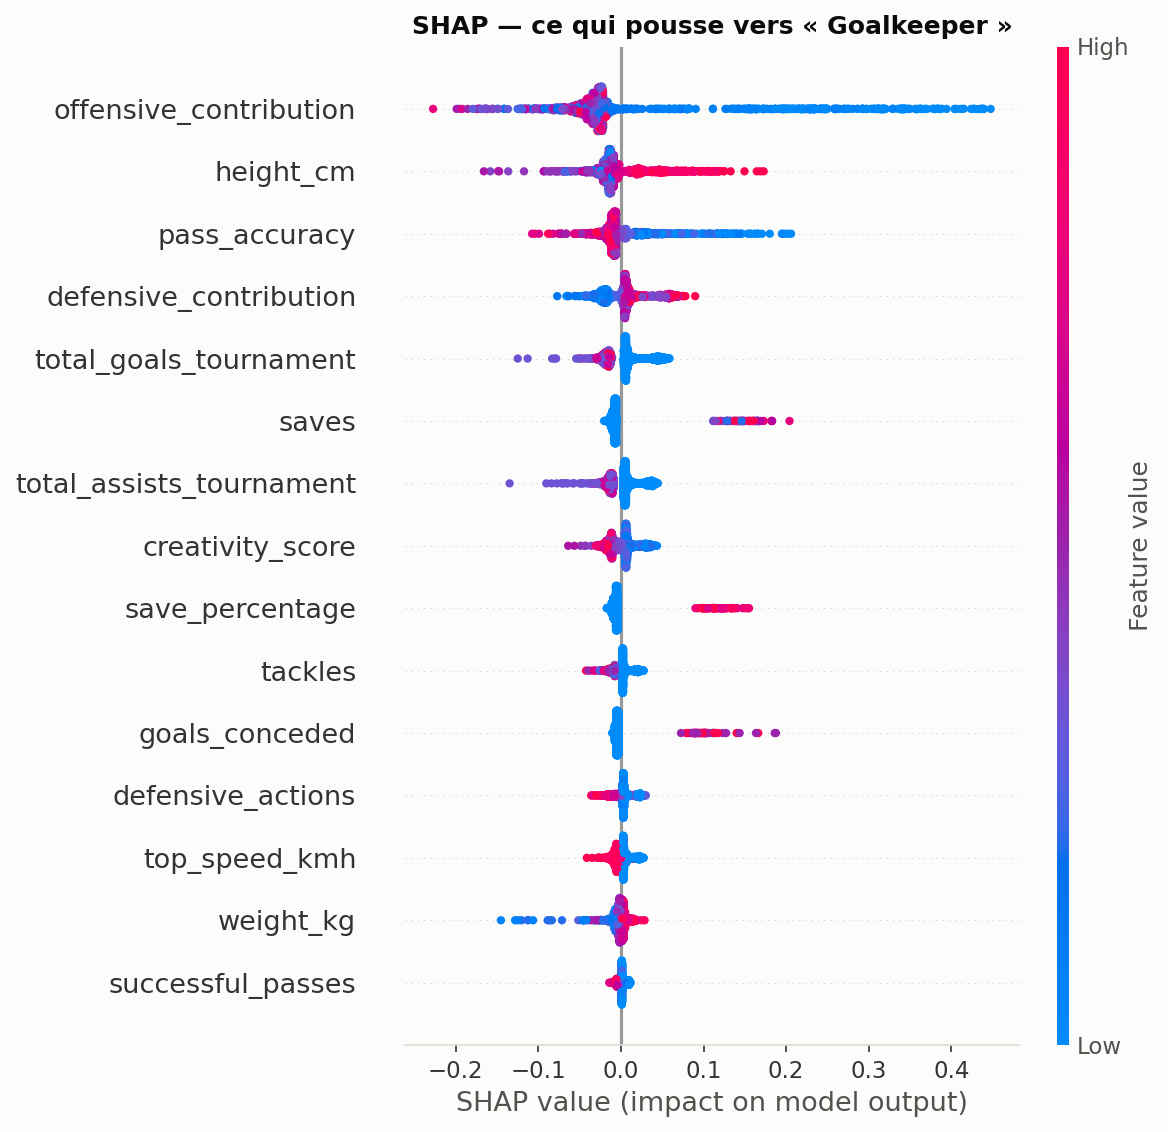

In [ ]:
import shap

explainer = shap.TreeExplainer(modeles["Random Forest"].best_estimator_)
X_sample = X_test.sample(1500, random_state=42)      # echantillon : SHAP est couteux
shap_values = explainer.shap_values(X_sample)

# on isole la classe Goalkeeper
i_gk = list(modeles["Random Forest"].best_estimator_.classes_).index("Goalkeeper")
shap.summary_plot(shap_values[:, :, i_gk], X_sample, show=False, max_display=15)
plt.savefig("resultats/shap_summary_gardien.png", dpi=150, bbox_inches="tight")
plt.show()

**Lecture :** chaque point est un joueur ; rouge = valeur haute de la variable, bleu = valeur basse ;
à droite = pousse vers « Gardien ». On lit clairement que des valeurs **basses** de contribution
offensive et défensive (bleu à droite) poussent vers le poste de gardien — logique, un gardien ne
participe ni au pressing ni à l'attaque.

### SHAP waterfall — un gardien en particulier

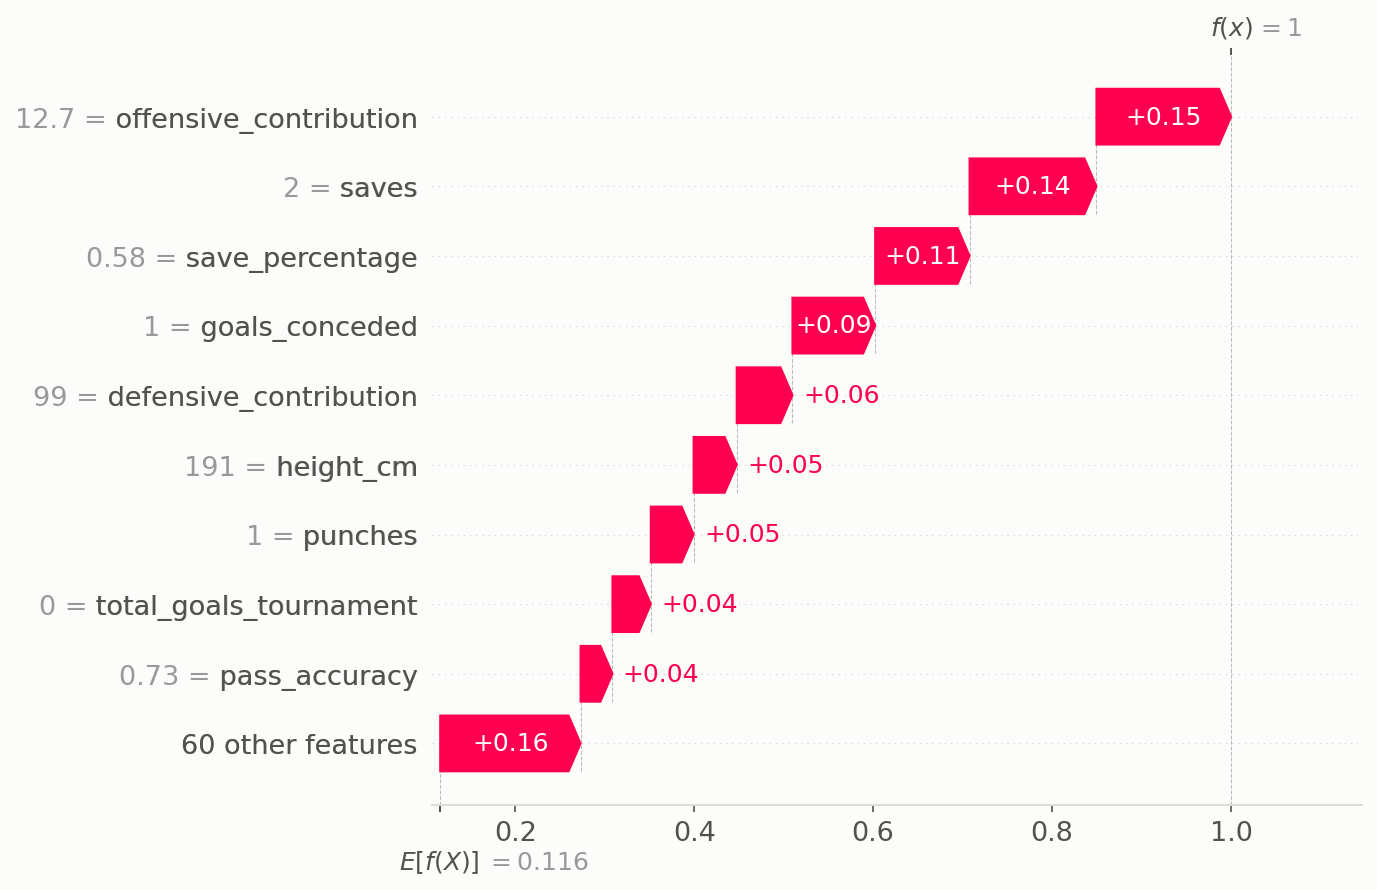

In [ ]:
k = int(np.argmax((y_test.loc[X_sample.index] == "Goalkeeper").values))  # 1er gardien de l'echantillon

shap.plots.waterfall(shap.Explanation(
    values=shap_values[k, :, i_gk],
    base_values=explainer.expected_value[i_gk],
    data=X_sample.iloc[k],
    feature_names=list(X_sample.columns)), show=False)
plt.savefig("resultats/shap_waterfall_gardien.png", dpi=150, bbox_inches="tight")
plt.show()

On part de la probabilité moyenne d'être gardien (~11,5 %, la part des gardiens dans les données)
et on suit variable par variable la construction de la prédiction finale. Rouge = pousse vers
« Gardien », bleu = éloigne. Pour ce joueur, l'absence de contribution offensive et défensive
suffit à faire basculer la prédiction.

## Partie 3 — Apprentissage non supervisé

La cible n'est **jamais** utilisée pour construire les projections ni les clusters. Elle ne sert
qu'à interpréter les résultats *a posteriori*.

> **Précaution méthodologique.** La colonne `position` est retirée des données avant standardisation.
> L'oublier rendrait toute l'analyse circulaire : on « découvrirait » une structure liée au poste
> simplement parce qu'on l'aurait mise dans les variables d'entrée.

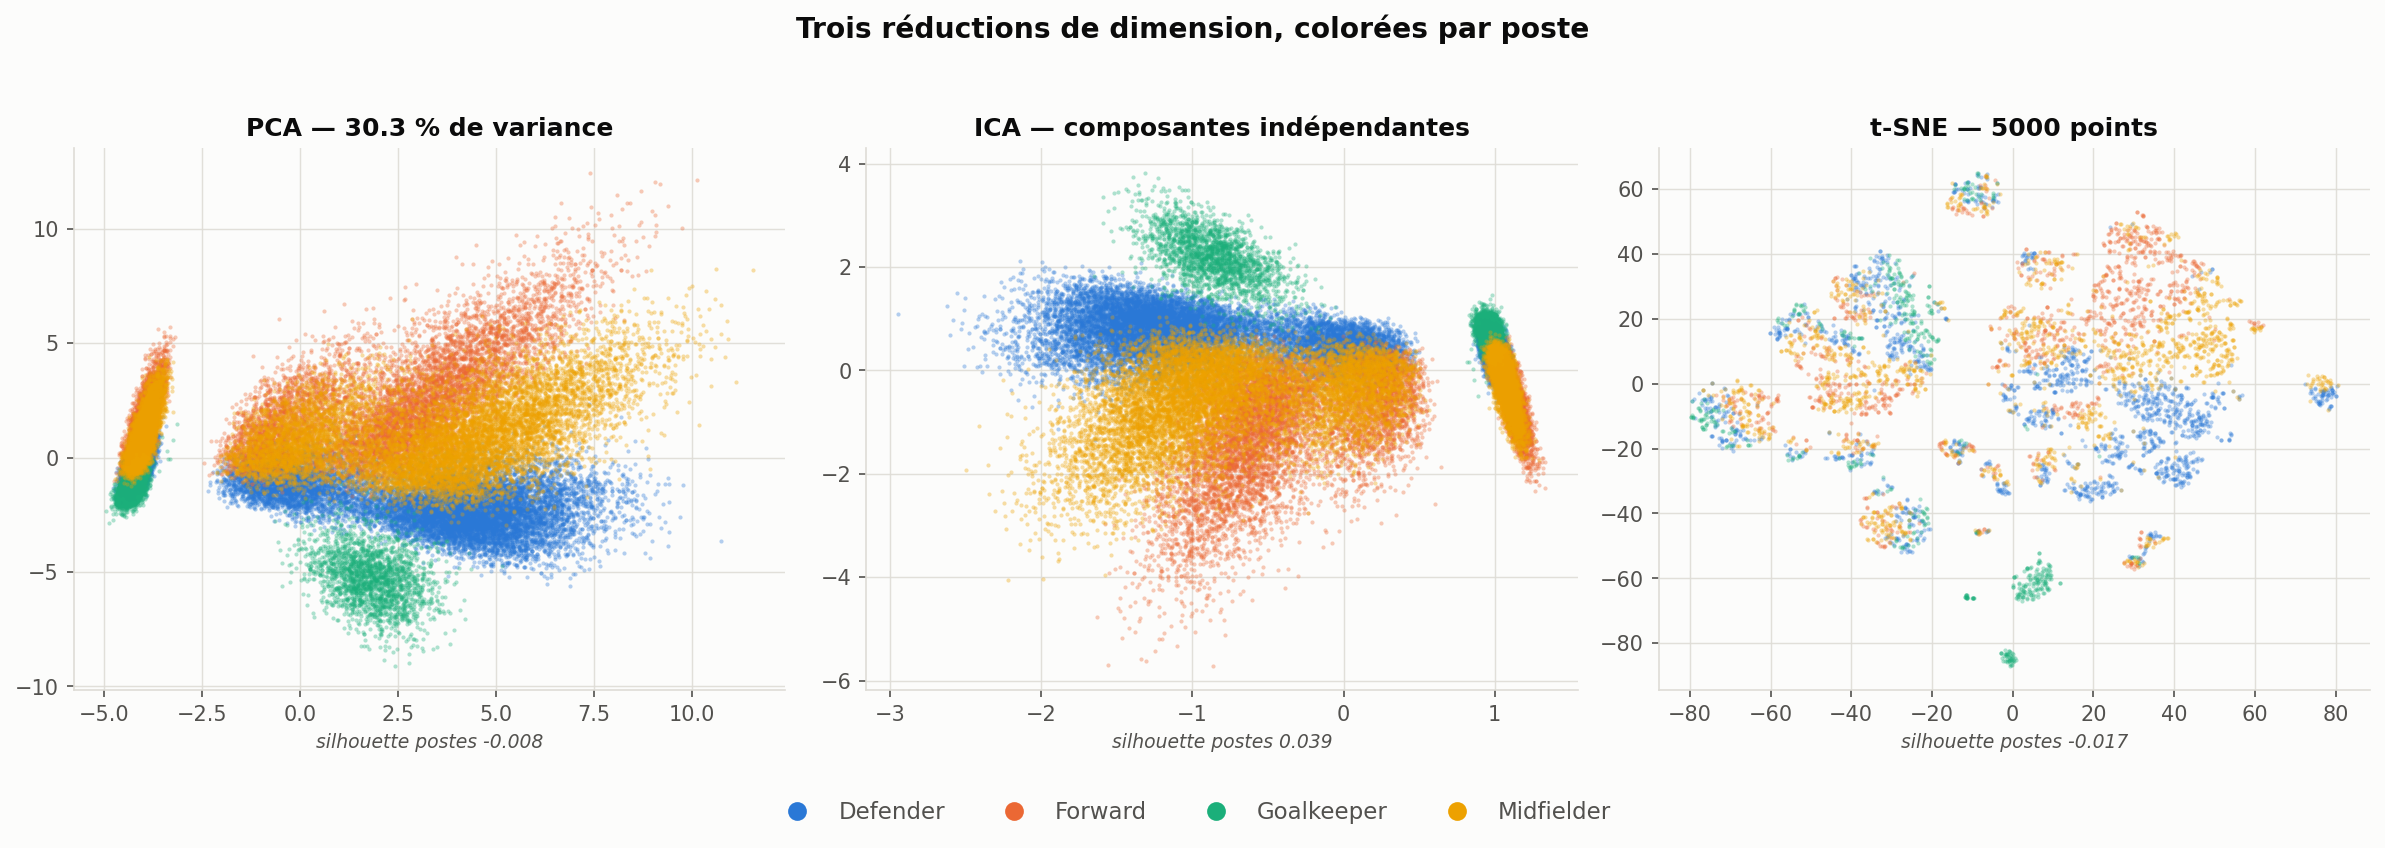

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FastICA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

X_all = df_final.drop(columns=["position"])          # <-- la cible est bien retiree
X_scaled = StandardScaler().fit_transform(X_all)

X_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
X_ica = FastICA(n_components=2, random_state=42, max_iter=500,
                whiten="unit-variance").fit_transform(X_scaled)

N = 5000                                              # t-SNE est quadratique -> echantillon
idx = np.random.RandomState(42).choice(len(X_scaled), N, replace=False)
X_pre = PCA(n_components=30, random_state=42).fit_transform(X_scaled[idx])
X_tsne = TSNE(n_components=2, perplexity=30, init="pca",
              random_state=42, max_iter=1000).fit_transform(X_pre)

plt.savefig("resultats/comparaison_reduction_dimension.png", dpi=150, bbox_inches="tight")
plt.show()

### Le résultat le plus surprenant du projet

| Technique | Silhouette selon les postes réels |
|---|---|
| PCA (30.3 % de variance) | **-0.008** |
| ICA | **+0.039** |
| t-SNE | **-0.017** |

Ces scores sont **nuls, voire négatifs**. Autrement dit : dans l'espace réduit, les postes **ne se
séparent pas du tout** — alors qu'on vient de les prédire à 95,8 % en supervisé.

### Le clustering confirme

In [ ]:
from sklearn.cluster import KMeans, DBSCAN

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)   # 4 clusters = 4 postes
clusters = kmeans.fit_predict(X_scaled)

# purete : si on assigne a chaque cluster le poste majoritaire, quelle part est correcte ?
table = pd.crosstab(clusters, df["position"])
purete = table.max(axis=1).sum() / table.values.sum()
print(f"silhouette = {silhouette_score(X_scaled, clusters, sample_size=5000, random_state=42):.3f}")
print(f"purete vis-a-vis des postes = {purete:.3f}")
table

silhouette = 0.147
purete vis-a-vis des postes = 0.425

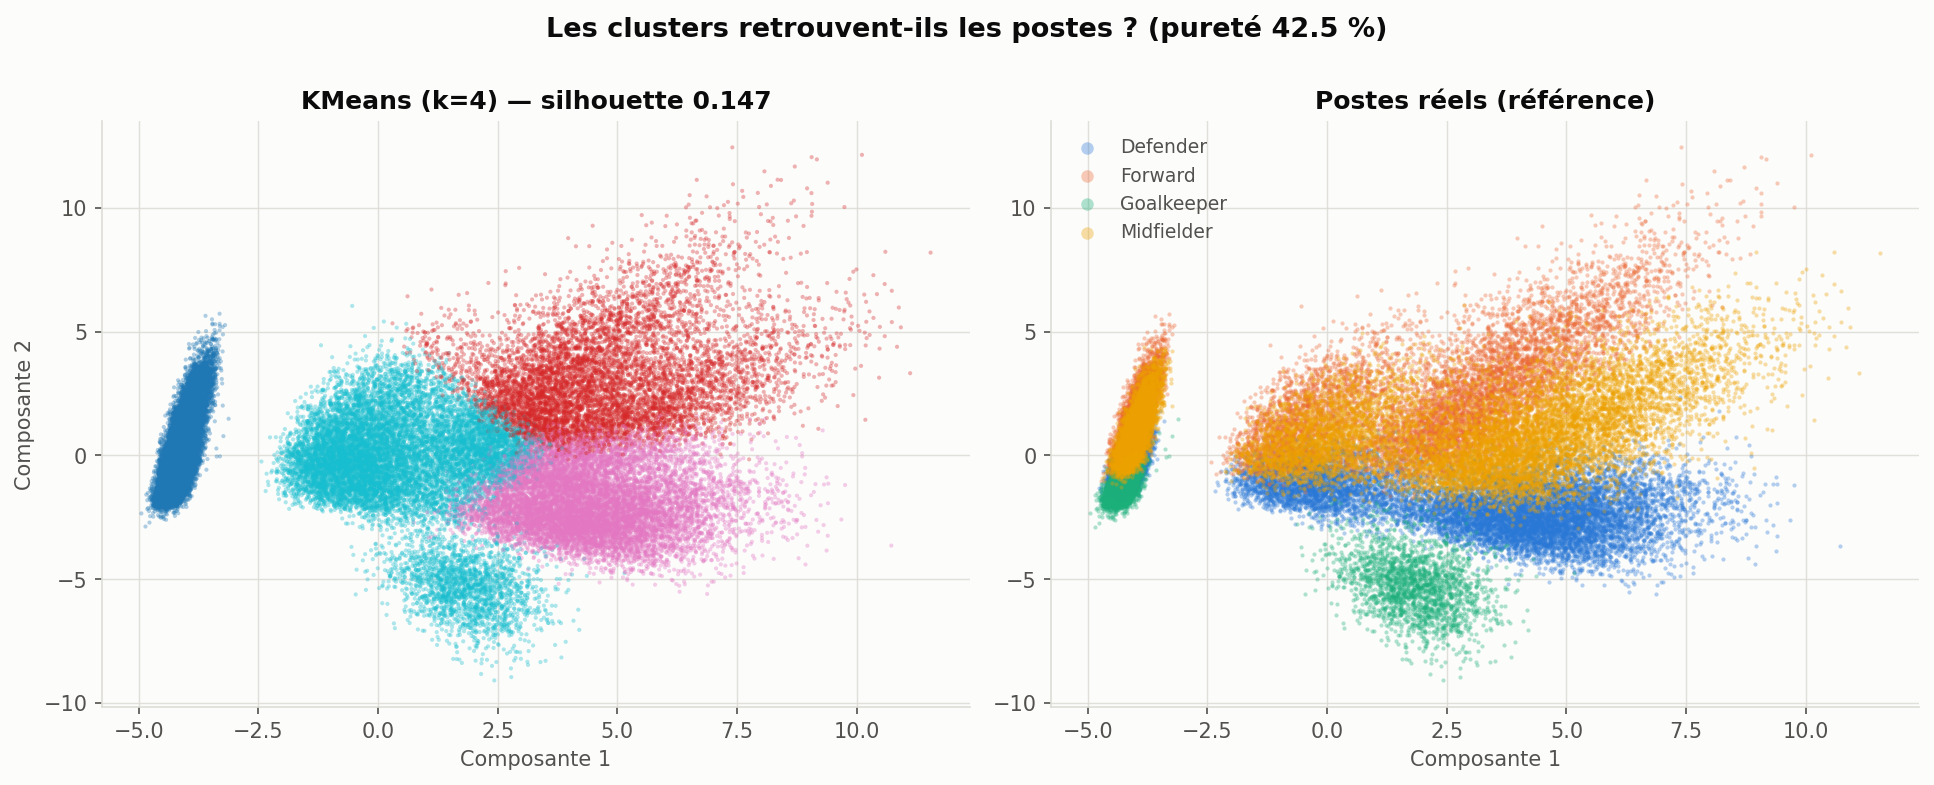

In [ ]:
# clusters trouves vs postes reels, cote a cote
plt.savefig("resultats/kmeans_vs_postes.png", dpi=150, bbox_inches="tight")
plt.show()

**Pureté de 42.5 %** : en attribuant à chaque cluster le poste majoritaire qu'il contient,
on ne classe correctement que 4 joueurs sur 10. Un tirage au sort pondéré ferait déjà ~30 %. Les
clusters ne correspondent donc **pas** aux postes.

DBSCAN donne le même verdict : il isole 31,515 et 23,042 points
(+ 43 de bruit) — une découpe qui ne recoupe pas non plus les 4 postes.

## Conclusion — la leçon principale de ce projet

**Le contraste entre les deux parties est le vrai résultat :**

| | Score |
|---|---|
| Prédiction supervisée du poste | **95,8 %** de F1 macro |
| Pureté des clusters non supervisés | **42.5 %** |

Comment un signal aussi fort peut-il être invisible en non supervisé ?

Parce que ces deux familles de méthodes cherchent des choses différentes :

- **Le supervisé sait quoi chercher.** On lui donne la réponse, il peut isoler les quelques
  variables qui discriminent (`defensive_contribution`, `offensive_contribution`…) et les combiner
  finement, même si elles ne représentent qu'une petite partie de la variabilité totale.
- **Le non supervisé cherche la variance dominante.** PCA et KMeans se laissent guider par ce qui
  varie le plus dans les 69 variables — et ici, ce qui varie le plus, c'est le **niveau de
  performance** d'un joueur sur un match (a-t-il beaucoup joué, beaucoup touché le ballon), pas
  son poste. Le signal « poste » existe, mais il est **noyé** dans une variance plus grande.

**Ce que ça enseigne :** l'absence de structure visible en clustering ne signifie pas l'absence de
signal exploitable. C'est exactement l'inverse de l'intuition courante, et c'est démontré ici par
deux mesures indépendantes sur le même jeu de données.

### Bilan méthodologique

- Détection et exclusion d'une **fuite de données** (`jersey_number`, plages disjointes par poste) ;
- séparation train/test **par joueur**, indispensable quand la cible est constante par individu ;
- choix du **F1 macro** face à un déséquilibre 3:1 ;
- accord entre importance **native et par permutation**, validant les variables retenues ;
- **SHAP** pour expliquer une classe (Gardien) globalement puis un joueur individuellement ;
- comparaison de **trois** réductions de dimension et de **deux** algorithmes de clustering.